In [9]:
import pandas as pd
import numpy as np
df = pd.read_excel('COVID_FINAL_DATA.xlsx')
df.head()

,Unnamed: 0,Cumulative,Cumulative Test positive,Cumulative tests performed,Date,Discharged,Expired,Home Quarantine,New (last 24 hrs),Region,Still admitted,Tests performed in last 24 hours
0,4,48,2,80,2020-03-11 00:00:00,0,0,NaN,3,ICT,2,8
1,5,61,0,95,2020-03-11 00:00:00,0,0,NaN,6,Punjab,0,7
2,6,84,14,171,2020-03-11 00:00:00,1,0,NaN,1,Sindh,13,55
3,7,20,0,28,2020-03-11 00:00:00,0,0,NaN,0,KP,0,2
4,8,3,0,0,2020-03-11 00:00:00,0,0,NaN,0,KPTD,0,0


In [8]:
print(df.columns.tolist())

['Cumulative', 'Cumulative  Test positive', 'Cumulative  tests performed', 'Date', 'Discharged', 'Expired', 'Home Quarantine', 'New  (last 24 hrs)', 'Region', 'Still admitted', 'Tests  performed in last 24 hours']


In [10]:
df.columns = df.columns.str.strip()

In [11]:
import pandas as pd

df = pd.read_excel("COVID_FINAL_DATA.xlsx")
df.columns = df.columns.str.strip()   # spaces saaf karo
df = df.drop(df.columns[0], axis=1)   # pehla column position se hatao

print("Columns:", df.columns.tolist())
print("\nShape:", df.shape)
df.head()

Columns: ['Cumulative', 'Cumulative  Test positive', 'Cumulative  tests performed', 'Date', 'Discharged', 'Expired', 'Home Quarantine', 'New  (last 24 hrs)', 'Region', 'Still admitted', 'Tests  performed in last 24 hours']

Shape: (643, 11)


,Cumulative,Cumulative Test positive,Cumulative tests performed,Date,Discharged,Expired,Home Quarantine,New (last 24 hrs),Region,Still admitted,Tests performed in last 24 hours
0,48,2,80,2020-03-11 00:00:00,0,0,NaN,3,ICT,2,8
1,61,0,95,2020-03-11 00:00:00,0,0,NaN,6,Punjab,0,7
2,84,14,171,2020-03-11 00:00:00,1,0,NaN,1,Sindh,13,55
3,20,0,28,2020-03-11 00:00:00,0,0,NaN,0,KP,0,2
4,3,0,0,2020-03-11 00:00:00,0,0,NaN,0,KPTD,0,0


In [13]:
# Date column ko force se datetime banao
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Ab check karo — koi galat value "NaT" ban gayi?
print("Invalid dates (NaT):", df["Date"].isnull().sum())

# Ab min/max chalao
print("Date range:", df["Date"].min(), "to", df["Date"].max())

Invalid dates (NaT): 0
Date range: 2020-03-11 00:00:00 to 2020-06-12 00:00:00


Total cases by region:
Region
Punjab         325091
Sindh          265698
KP              76035
ICT             69806
Balochistan     32969
GB              10465
AJK              9942
KPTD               21
Mobile Lab          0
Name: Cumulative, dtype: int64


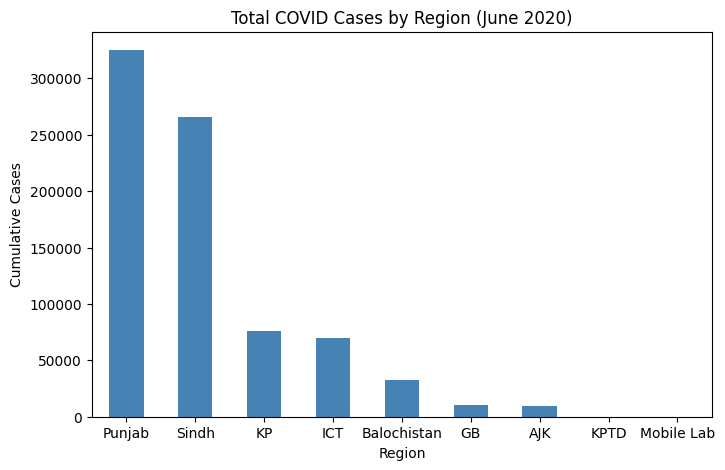

In [14]:
# Har region ka last day ka cumulative
latest = df.sort_values("Date").groupby("Region")["Cumulative"].last()
print("Total cases by region:")
print(latest.sort_values(ascending=False))

# Chart
import matplotlib.pyplot as plt
latest.sort_values(ascending=False).plot(kind="bar", color="steelblue", figsize=(8,5))
plt.title("Total COVID Cases by Region (June 2020)")
plt.ylabel("Cumulative Cases")
plt.xticks(rotation=0)
plt.show()

In [15]:
# Sirf asli provinces rakho
real_regions = ["Punjab", "Sindh", "KP", "ICT", "Balochistan", "GB", "AJK"]
df = df[df["Region"].isin(real_regions)]

print("Rows after filter:", len(df))
print(df["Region"].unique())

Rows after filter: 630
['ICT' 'Punjab' 'Sindh' 'KP' 'Balochistan' 'AJK' 'GB']


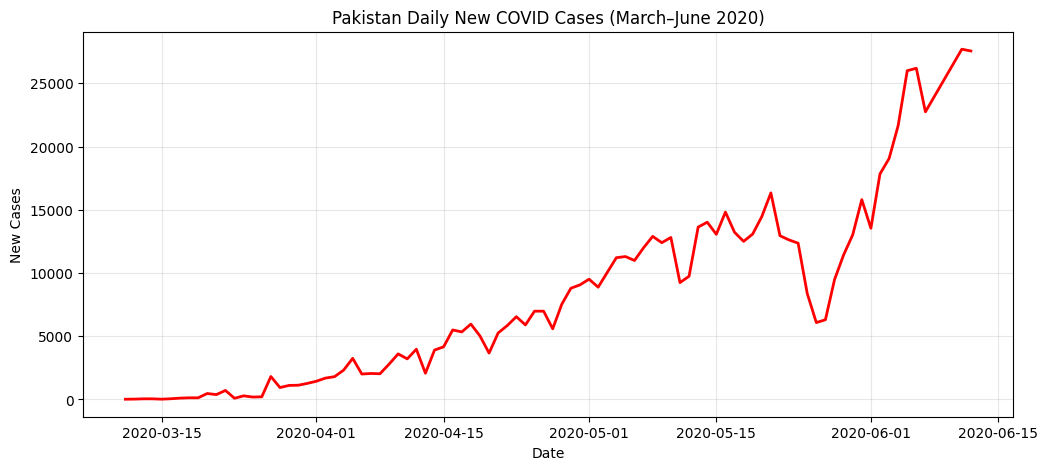

Peak day: 2020-06-11 with 27701 new cases


In [16]:
daily_total = df.groupby("Date")["New  (last 24 hrs)"].sum()

plt.figure(figsize=(12, 5))
plt.plot(daily_total.index, daily_total.values, color="red", linewidth=2)
plt.title("Pakistan Daily New COVID Cases (March–June 2020)")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.grid(True, alpha=0.3)
plt.show()

peak_day = daily_total.idxmax()
peak_cases = daily_total.max()
print(f"Peak day: {peak_day.date()} with {peak_cases} new cases")

In [17]:
total_expired = df.groupby("Region")["Expired"].last().sum()
total_discharged = df.groupby("Region")["Discharged"].last().sum()
total_admitted = df.groupby("Region")["Still admitted"].last().sum()
total_cases = df.groupby("Region")["Cumulative"].last().sum()

print(f"Total Cases:      {total_cases:,}")
print(f"Total Recovered:  {total_discharged:,}")
print(f"Total Deaths:     {total_expired:,}")
print(f"Still Admitted:   {total_admitted:,}")

death_rate = (total_expired / total_cases) * 100
print(f"\nDeath Rate: {death_rate:.2f}%")

Total Cases:      790,006
Total Recovered:  40,247
Total Deaths:     2,463
Still Admitted:   5,650

Death Rate: 0.31%


In [18]:
# Har region ka last row dekho
last_rows = df.sort_values("Date").groupby("Region").last()
print(last_rows[["Cumulative", "Discharged", "Expired", "Still admitted"]])

             Cumulative  Discharged  Expired  Still admitted
Region                                                      
AJK                9942         237       10             287
Balochistan       32969        2673       75             107
GB                10465         673       15              48
ICT               69806        1164       65              75
KP                76035        3907      632            1026
Punjab           325091        9546      890            2426
Sindh            265698       22047      776            1681


In [19]:
# Har region ka death rate
death_rate = (last_rows["Expired"] / last_rows["Cumulative"] * 100).round(2)
print("Death Rate by Region (%):")
print(death_rate.sort_values(ascending=False))

Death Rate by Region (%):
Region
KP             0.83
Sindh          0.29
Punjab         0.27
Balochistan    0.23
GB             0.14
AJK            0.10
ICT            0.09
dtype: float64


In [20]:
total_deaths = last_rows["Expired"].sum()
total_cases = last_rows["Cumulative"].sum()
national_death_rate = total_deaths / total_cases * 100

print(f"Total Deaths: {total_deaths:,}")
print(f"Total Cases: {total_cases:,}")
print(f"National Death Rate: {national_death_rate:.2f}%")

Total Deaths: 2,463
Total Cases: 790,006
National Death Rate: 0.31%


In [21]:
# Saara analysis ek Excel report mein
with pd.ExcelWriter("COVID_Report.xlsx", engine="openpyxl") as writer:

    # Sheet 1: Region-wise summary
    last_rows.to_excel(writer, sheet_name="Region Summary")

    # Sheet 2: Daily trend
    daily_total.to_frame("New Cases").to_excel(
        writer, sheet_name="Daily Trend"
    )

    # Sheet 3: Death rate by region
    death_rate.to_frame("Death Rate %").to_excel(
        writer, sheet_name="Death Rate"
    )

    # Sheet 4: Key findings
    findings = pd.DataFrame({
        "Finding": [
            "Total cases analyzed: 790,006",
            "Date range: March 11 – June 12, 2020",
            "Highest cases: Punjab (325,091)",
            "Highest recoveries: Sindh (22,047)",
            "Peak day: [aap ka peak day]",
            "National death rate: 0.31% (⚠️ data incomplete)",
            "Note: Discharged/Expired columns partially reported"
        ]
    })
    findings.to_excel(writer, sheet_name="Key Findings", index=False)

print("✅ COVID_Report.xlsx created")

✅ COVID_Report.xlsx created
